# Libraries

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, wilcoxon

from src.dominick import DominickDataLoader

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams.update({
    "axes.titlesize": 18,   # size of the titles of each subplot
    "axes.labelsize": 16,   # size of the labels of the axes (xlabel/ylabel)
    "xtick.labelsize": 13,  # size of the numbers/ticks of the x-axis
    "ytick.labelsize": 13,  # size of the numbers/ticks of the y-axis
})

# Configuration and Data Loading

In [2]:
loader = DominickDataLoader()

def load(path):
    df = loader.load(path)
    print(f"  {path}: {df.shape}")
    return df

_q025 = lambda s: np.percentile(s, 2.5)
_q975 = lambda s: np.percentile(s, 97.5)

print("=== NN ===")
nn_kfold      = load("nn_kfold_metrics_raw.csv")
nn_kfold_elas = load("nn_kfold_elasticities_raw.csv")
nn_boot_raw   = load("nn_bootstrap_elasticities_raw.csv")

nn_boot_own_per_run = (
    nn_boot_raw[nn_boot_raw["type"] == "own"]
    .groupby(["store_code", "upc_i", "bootstrap_run"], as_index=False)
    .agg(E_run=("E", "mean"))
)
nn_boot_own = (
    nn_boot_own_per_run
    .groupby(["store_code", "upc_i"], as_index=False)
    .agg(
        elasticity_mean   =("E_run", "mean"),
        elasticity_std    =("E_run", "std"),
        elasticity_ci_low =("E_run", _q025),
        elasticity_ci_high=("E_run", _q975),
        n_obs             =("E_run", "count"),
    )
    .rename(columns={"upc_i": "upc_code"})
)
nn_boot_cross_per_run = (
    nn_boot_raw[nn_boot_raw["type"] == "cross"]
    .groupby(["store_code", "upc_i", "upc_j", "bootstrap_run"], as_index=False)
    .agg(E_run=("E", "mean"))
)
nn_boot_cross = (
    nn_boot_cross_per_run
    .groupby(["store_code", "upc_i", "upc_j"], as_index=False)
    .agg(
        elasticity_mean   =("E_run", "mean"),
        elasticity_std    =("E_run", "std"),
        elasticity_ci_low =("E_run", _q025),
        elasticity_ci_high=("E_run", _q975),
        n_obs             =("E_run", "count"),
    )
)

print("\n=== Benchmark ===")
bench_kfold    = load("benchmark_kfold_raw.csv")
bench_boot_sum = load("benchmark_elasticities_bootstrap_summary.csv")
bench_boot_raw = load("benchmark_bootstrap_raw.csv")

bench_gen_folds = bench_kfold.copy()

bench_cross_folds = (
    bench_kfold[["store_code", "fold", "upc_i", "upc_j", "cross_elasticity"]]
    .rename(columns={
        "upc_i": "upc_a",
        "upc_j": "upc_b",
        "cross_elasticity": "cross_elasticity_sym",
    })
)

bench_cross_boot = (
    bench_boot_raw
    .rename(columns={"upc_i": "upc_a", "upc_j": "upc_b"})
    .groupby(["store_code", "upc_a", "upc_b"], as_index=False)
    .agg(
        cross_elasticity_sym_mean   =("cross_elasticity", "mean"),
        cross_elasticity_sym_std    =("cross_elasticity", "std"),
        cross_elasticity_sym_ci_low =("cross_elasticity", _q025),
        cross_elasticity_sym_ci_high=("cross_elasticity", _q975),
    )
)

print("\n=== Ridge (regularized) ===")
ridge_kfold    = load("benchmark_ridge_kfold_raw.csv")
ridge_boot_sum = load("benchmark_ridge_elasticities_bootstrap_summary.csv")
ridge_boot_raw = load("benchmark_ridge_bootstrap_raw.csv")

ridge_gen_folds = ridge_kfold.copy()

ridge_cross_folds = (
    ridge_kfold[["store_code", "fold", "upc_i", "upc_j", "cross_elasticity"]]
    .rename(columns={"upc_i": "upc_a", "upc_j": "upc_b", "cross_elasticity": "cross_elasticity_sym"})
)

ridge_cross_boot = (
    ridge_boot_raw
    .rename(columns={"upc_i": "upc_a", "upc_j": "upc_b"})
    .groupby(["store_code", "upc_a", "upc_b"], as_index=False)
    .agg(
        cross_elasticity_sym_mean=("cross_elasticity", "mean"),
        cross_elasticity_sym_std=("cross_elasticity", "std"),
        cross_elasticity_sym_ci_low=("cross_elasticity", _q025),
        cross_elasticity_sym_ci_high=("cross_elasticity", _q975),
    )
)

=== NN ===
  nn_kfold_metrics_raw.csv: (25, 7)
  nn_kfold_elasticities_raw.csv: (698425, 12)
  nn_bootstrap_elasticities_raw.csv: (878180, 12)

=== Benchmark ===
  benchmark_kfold_raw.csv: (3944, 19)
  benchmark_elasticities_bootstrap_summary.csv: (544, 18)
  benchmark_bootstrap_raw.csv: (10880, 19)

=== Ridge (regularized) ===
  benchmark_ridge_kfold_raw.csv: (3944, 14)
  benchmark_ridge_elasticities_bootstrap_summary.csv: (544, 18)
  benchmark_ridge_bootstrap_raw.csv: (10880, 14)


In [3]:
print("\n=== MLP (demand-first, Jacobian) ===")
mlp_kfold_elas    = load("benchmark_mlp_kfold_raw.csv")
mlp_boot_elas_raw = load("benchmark_mlp_bootstrap_raw.csv")

def _collapse_mlp(df, extra_group_col):
    """Una fila por (store, upc_i, upc_j, extra): own = E_ii, cross = E_ij.
    Métricas de demanda se calculan en celdas (store, upc_i, week), no por par j.
    """
    group_ij = ["store_code", "upc_i", "upc_j", extra_group_col]
    group_i  = ["store_code", "upc_i", extra_group_col]

    own = (
        df[df["type"] == "own"]
        .groupby(group_i, as_index=False)
        .agg(own_elasticity=("E", "mean"))
    )
    cross = (
        df[df["type"] == "cross"]
        .groupby(group_ij, as_index=False)
        .agg(cross_elasticity=("E", "mean"), n_obs=("E", "size"))
    )
    out = cross.merge(own, on=group_i, how="left")

    pred = (
        df[df["type"] == "own"]
        .drop_duplicates(["store_code", "upc_i", "week_id", extra_group_col]
                         + (["seed"] if "seed" in df.columns else []))
        [["store_code", "upc_i", extra_group_col, "y_true_i", "y_hat_i"]]
        .copy()
    )
    pred["abs_err"] = (pred["y_true_i"] - pred["y_hat_i"]).abs()
    pred["sq_err"] = (pred["y_true_i"] - pred["y_hat_i"]) ** 2
    pred["y_true_group_mean"] = pred.groupby(group_i)["y_true_i"].transform("mean")
    pred["sq_dev"] = (pred["y_true_i"] - pred["y_true_group_mean"]) ** 2
    err_g = pred.groupby(group_i, as_index=False).agg(
        mae_val=("abs_err", "mean"),
        rmse_val=("sq_err", lambda s: np.sqrt(s.mean())),
        ss_res=("sq_err", "sum"),
        ss_tot=("sq_dev", "sum"),
    )
    err_g["r2_val"] = np.where(err_g["ss_tot"] == 0, np.nan, 1 - err_g["ss_res"] / err_g["ss_tot"])
    err_g = err_g.drop(columns=["ss_res", "ss_tot"])

    out = out.merge(err_g, on=group_i)
    out["status"] = "ok"
    return out

mlp_kfold = _collapse_mlp(mlp_kfold_elas, "fold")
mlp_gen_folds = mlp_kfold.copy()

mlp_cross_folds = (
    mlp_kfold[["store_code", "fold", "upc_i", "upc_j", "cross_elasticity"]]
    .rename(columns={"upc_i": "upc_a", "upc_j": "upc_b", "cross_elasticity": "cross_elasticity_sym"})
)

mlp_boot_summary = _collapse_mlp(mlp_boot_elas_raw, "bootstrap_run")
mlp_boot_raw = mlp_boot_summary.copy()

mlp_boot_sum = (
    mlp_boot_summary
    .groupby(["store_code", "upc_i", "upc_j"], as_index=False)
    .agg(
        own_elasticity_mean=("own_elasticity", "mean"),
        own_elasticity_std=("own_elasticity", "std"),
        own_elasticity_ci_low=("own_elasticity", _q025),
        own_elasticity_ci_high=("own_elasticity", _q975),
        cross_elasticity_mean=("cross_elasticity", "mean"),
        cross_elasticity_std=("cross_elasticity", "std"),
        cross_elasticity_ci_low=("cross_elasticity", _q025),
        cross_elasticity_ci_high=("cross_elasticity", _q975),
    )
)

mlp_cross_boot = (
    mlp_boot_summary
    .rename(columns={"upc_i": "upc_a", "upc_j": "upc_b"})
    .groupby(["store_code", "upc_a", "upc_b"], as_index=False)
    .agg(
        cross_elasticity_sym_mean=("cross_elasticity", "mean"),
        cross_elasticity_sym_std=("cross_elasticity", "std"),
        cross_elasticity_sym_ci_low=("cross_elasticity", _q025),
        cross_elasticity_sym_ci_high=("cross_elasticity", _q975),
    )
)


=== MLP (demand-first, Jacobian) ===
  benchmark_mlp_kfold_raw.csv: (698425, 13)
  benchmark_mlp_bootstrap_raw.csv: (878180, 13)


In [4]:
# ============================================================
# Global-pooled fold metrics (Point 1 fix): same aggregation unit as ICDN.
# MLP already has a correct global-pooled file (no code change needed);
# OLS/Ridge need their per-observation predictions collapsed across partner
# UPCs j and then pooled globally per fold, instead of averaging many small
# per-group R^2 values.
# ============================================================

mlp_kfold_global = load("benchmark_mlp_kfold_metrics_raw.csv")

ols_predictions   = load("benchmark_kfold_predictions_raw.csv")
ridge_predictions = load("benchmark_ridge_kfold_predictions_raw.csv")

def collapse_across_j(predictions_df):
    """Averages y_hat_i across all partner UPCs j paired with the same focal
    UPC i, collapsing the directed-pair predictions down to one prediction per
    (store, upc_i, week, fold) -- the same unit ICDN predicts natively."""
    return predictions_df.groupby(["store_code", "upc_i", "week_id", "fold"], as_index=False).agg(
        y_true_i=("y_true_i", "mean"), y_hat_i=("y_hat_i", "mean"),
    )

def pooled_global_metrics_by_fold(collapsed_df):
    """Pools residuals across ALL (store, upc_i, week) observations within a
    fold before computing MAE/RMSE/R^2 -- matches compute_global_metrics used
    for ICDN, instead of averaging many small per-group R^2 values."""
    rows = []
    for fold, g in collapsed_df.groupby("fold"):
        resid = g["y_true_i"] - g["y_hat_i"]
        ss_res = (resid ** 2).sum()
        ss_tot = ((g["y_true_i"] - g["y_true_i"].mean()) ** 2).sum()
        rows.append({
            "fold": fold, "n_obs": len(g),
            "mae_val_o": resid.abs().mean(),
            "rmse_val_o": np.sqrt((resid ** 2).mean()),
            "r2_val_o": np.nan if ss_tot == 0 else 1 - ss_res / ss_tot,
        })
    return pd.DataFrame(rows)

ols_global_by_fold   = pooled_global_metrics_by_fold(collapse_across_j(ols_predictions))
ridge_global_by_fold = pooled_global_metrics_by_fold(collapse_across_j(ridge_predictions))
mlp_global_by_fold = (
    mlp_kfold_global
    .groupby("fold", as_index=False)
    .agg(mae_val_o=("mae_val", "mean"), rmse_val_o=("rmse_val", "mean"), r2_val_o=("r2_val", "mean"))
)

GLOBAL_FOLD_TABLES = {"OLS": ols_global_by_fold, "Ridge": ridge_global_by_fold, "MLP": mlp_global_by_fold}

print("Global (pooled) fold-level metrics ready.")
for label, t in GLOBAL_FOLD_TABLES.items():
    print(f"  {label}: r2_val_o by fold = {t['r2_val_o'].round(3).tolist()}")

  benchmark_mlp_kfold_metrics_raw.csv: (25, 10)
  benchmark_kfold_predictions_raw.csv: (103226, 8)
  benchmark_ridge_kfold_predictions_raw.csv: (103226, 8)
Global (pooled) fold-level metrics ready.
  OLS: r2_val_o by fold = [0.429, 0.736, 0.628, 0.209, 0.335]
  Ridge: r2_val_o by fold = [0.741, 0.781, 0.652, 0.492, 0.423]
  MLP: r2_val_o by fold = [0.781, 0.768, 0.581, 0.48, 0.467]


In [5]:
def cell_level_metrics_from_predictions(collapsed_df):
    """Computes MAE/RMSE at the (store, upc_i, fold) level from predictions
    ALREADY averaged across partner UPCs j (collapse_across_j) -- consistent
    with the fold-level global fix. Averaging predictions before taking the
    absolute error (instead of averaging per-j MAEs) avoids overstating the
    error via the triangle inequality: |y - mean_j(y_hat_j)| <= mean_j|y - y_hat_j|."""
    g = collapsed_df.copy()
    g["resid"] = g["y_true_i"] - g["y_hat_i"]
    return g.groupby(["store_code", "upc_i", "fold"], as_index=False).agg(
        mae_val_o=("resid", lambda s: s.abs().mean()),
        rmse_val_o=("resid", lambda s: np.sqrt((s ** 2).mean())),
    )

# MLP predictions, in the same (store, upc_i, upc_j, week_id, fold, y_true_i,
# y_hat_i) shape as ols_predictions/ridge_predictions, now that week_id exists.
mlp_pred = mlp_kfold_elas[mlp_kfold_elas["type"] == "own"].copy()

keys = ["store_code", "upc_i", "week_id", "fold"]
if "seed" in mlp_pred.columns:
    keys = keys + ["seed"]

mlp_collapsed = mlp_pred.groupby(keys, as_index=False).agg(
    y_true_i=("y_true_i", "mean"), y_hat_i=("y_hat_i", "mean"),
)

mlp_cell_metrics = cell_level_metrics_from_predictions(mlp_collapsed)
if "seed" in mlp_collapsed.columns:
    mlp_cell_metrics = mlp_cell_metrics.groupby(
        ["store_code", "upc_i", "fold"], as_index=False
    ).agg(mae_val_o=("mae_val_o", "mean"), rmse_val_o=("rmse_val_o", "mean"))

ols_cell_metrics   = cell_level_metrics_from_predictions(collapse_across_j(ols_predictions))
ridge_cell_metrics = cell_level_metrics_from_predictions(collapse_across_j(ridge_predictions))

CELL_METRICS_TABLES = {"OLS": ols_cell_metrics, "Ridge": ridge_cell_metrics, "MLP": mlp_cell_metrics}
print("Cell-level (store, upc_i, fold) metrics ready -- predictions averaged across j BEFORE computing MAE/RMSE.")

Cell-level (store, upc_i, fold) metrics ready -- predictions averaged across j BEFORE computing MAE/RMSE.


# Model Registry

In [6]:
# ============================================================
# Model registry + ICDN / MLP elasticity reference tables
# ============================================================
MODEL_LABELS = ["OLS", "Ridge", "MLP"]
MODEL_TABLES = {
    "OLS":   {"kfold": bench_kfold, "boot_sum": bench_boot_sum},
    "Ridge": {"kfold": ridge_kfold, "boot_sum": ridge_boot_sum},
    "MLP":   {"kfold": mlp_kfold,   "boot_sum": mlp_boot_sum},
}
MODEL_COLORS = {"OLS": "coral", "Ridge": "seagreen", "MLP": "goldenrod", "ICDN": "steelblue"}

nn_by_fold_ref = nn_kfold.groupby("fold", as_index=False).agg(
    mae_val_nn=("mae_val", "mean"), rmse_val_nn=("rmse_val", "mean"), r2_val_nn=("r2_val", "mean"),
)

nn_own_local = nn_kfold_elas[nn_kfold_elas["type"] == "own"].copy()
nn_own_local["abs_error"] = (nn_own_local["y_true_i"] - nn_own_local["y_hat_i"]).abs()
nn_own_local["sq_error"]  = (nn_own_local["y_true_i"] - nn_own_local["y_hat_i"]) ** 2

nn_pair_seed_ref = nn_own_local.groupby(["store_code", "upc_i", "fold", "seed"], as_index=False).agg(
    mae=("abs_error", "mean"), mse=("sq_error", "mean")
)
nn_pair_seed_ref["rmse"] = np.sqrt(nn_pair_seed_ref["mse"])
nn_pair_fold_ref = nn_pair_seed_ref.groupby(["store_code", "upc_i", "fold"], as_index=False).agg(
    mae_val_nn=("mae", "mean"), rmse_val_nn=("rmse", "mean")
)


def _mad(s):
    x = s.to_numpy(dtype=float)
    return np.nanmedian(np.abs(x - np.nanmedian(x)))


def elasticity_seed_stats(elas, keys):
    """A1: mismo fold / mismas semanas, distinta seed."""
    per_seed = elas.groupby(keys + ["fold", "seed"], as_index=False).agg(E_mean=("E", "mean"))
    return (
        per_seed.groupby(keys + ["fold"], as_index=False)
        .agg(E_seed_std=("E_mean", "std"), E_seed_mad=("E_mean", _mad), n_seeds=("E_mean", "count"))
    )


def elasticity_temporal_stats(elas, keys):
    """B: media de E por fold (seeds colapsados), luego std entre folds.
    No es reproducibilidad: es variación temporal de la elasticidad media.
    """
    per_fold = elas.groupby(keys + ["fold"], as_index=False).agg(E_mean=("E", "mean"))
    temporal = (
        per_fold.groupby(keys, as_index=False)
        .agg(E_temporal_std=("E_mean", "std"), n_folds=("E_mean", "count"))
    )
    return per_fold, temporal


# ---- ICDN own / cross ----
nn_own_seed_ref = elasticity_seed_stats(nn_own_local, ["store_code", "upc_i"])
nn_fold_E_ref, nn_temporal_std_ref = elasticity_temporal_stats(nn_own_local, ["store_code", "upc_i"])
nn_kfold_point_ref = nn_fold_E_ref.rename(columns={"E_mean": "E_fold"})

nn_cross_local = nn_kfold_elas[nn_kfold_elas["type"] == "cross"].copy()
nn_cross_seed_ref = elasticity_seed_stats(nn_cross_local, ["store_code", "upc_i", "upc_j"])
nn_cross_fold_E_ref, nn_cross_temporal_std_ref = elasticity_temporal_stats(
    nn_cross_local, ["store_code", "upc_i", "upc_j"]
)

# ---- MLP own / cross (raw k-fold, NO colapsar seeds) ----
mlp_own_local = mlp_kfold_elas[mlp_kfold_elas["type"] == "own"].copy()
mlp_cross_local = mlp_kfold_elas[mlp_kfold_elas["type"] == "cross"].copy()
mlp_own_seed_ref = elasticity_seed_stats(mlp_own_local, ["store_code", "upc_i"])
mlp_cross_seed_ref = elasticity_seed_stats(mlp_cross_local, ["store_code", "upc_i", "upc_j"])

print("ICDN + MLP reference tables ready.")

ICDN + MLP reference tables ready.


# B1 - Fold-level + pair-level generalization

In [7]:
# ============================================================
# BLOCK 1 — Generalization: ICDN vs OLS vs Ridge vs MLP
# ============================================================
def block1_stats(global_fold_table: pd.DataFrame, cell_metrics_table: pd.DataFrame):
    gen_fold = nn_by_fold_ref.merge(global_fold_table[["fold", "mae_val_o", "rmse_val_o", "r2_val_o"]], on="fold")
    gen_fold["delta_r2"]   = gen_fold["r2_val_nn"]   - gen_fold["r2_val_o"]
    gen_fold["delta_mae"]  = gen_fold["mae_val_nn"]  - gen_fold["mae_val_o"]
    gen_fold["delta_rmse"] = gen_fold["rmse_val_nn"] - gen_fold["rmse_val_o"]

    # cell_metrics_table is already built from predictions averaged across j
    # BEFORE computing |error| -- fixes the Jensen's-inequality bias.
    gen_cell = nn_pair_fold_ref.merge(cell_metrics_table, on=["store_code", "upc_i", "fold"])
    gen_cell["delta_mae"]  = gen_cell["mae_val_nn"]  - gen_cell["mae_val_o"]
    gen_cell["delta_rmse"] = gen_cell["rmse_val_nn"] - gen_cell["rmse_val_o"]
    return gen_fold, gen_cell

gen_fold_all, gen_cell_all = [], []
for label in MODEL_LABELS:
    gf, gc = block1_stats(GLOBAL_FOLD_TABLES[label], CELL_METRICS_TABLES[label])
    gf["model"], gc["model"] = label, label
    gen_fold_all.append(gf); gen_cell_all.append(gc)
gen_fold_all = pd.concat(gen_fold_all, ignore_index=True)
gen_cell_all = pd.concat(gen_cell_all, ignore_index=True)

print("=== Block 1a: fold-level paired t-test (ICDN vs each model) ===")
print("R^2/MAE/RMSE are now pooled globally per fold -- same unit as ICDN.")
for label in MODEL_LABELS:
    sub = gen_fold_all[gen_fold_all["model"] == label]
    line = f"  {label}: n_folds={len(sub)}  mean_delta_r2={sub['delta_r2'].mean():.4f}"
    if len(sub) >= 2:
        t, p = ttest_rel(sub["r2_val_nn"], sub["r2_val_o"])
        line += f"  t={t:.3f}  p={p:.4f}"
    print(line)

=== Block 1a: fold-level paired t-test (ICDN vs each model) ===
R^2/MAE/RMSE are now pooled globally per fold -- same unit as ICDN.
  OLS: n_folds=5  mean_delta_r2=0.1820  t=2.749  p=0.0514
  Ridge: n_folds=5  mean_delta_r2=0.0321  t=1.371  p=0.2423
  MLP: n_folds=5  mean_delta_r2=0.0343  t=2.125  p=0.1007


/tmp/ipykernel_243390/2924079996.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=MODEL_LABELS)


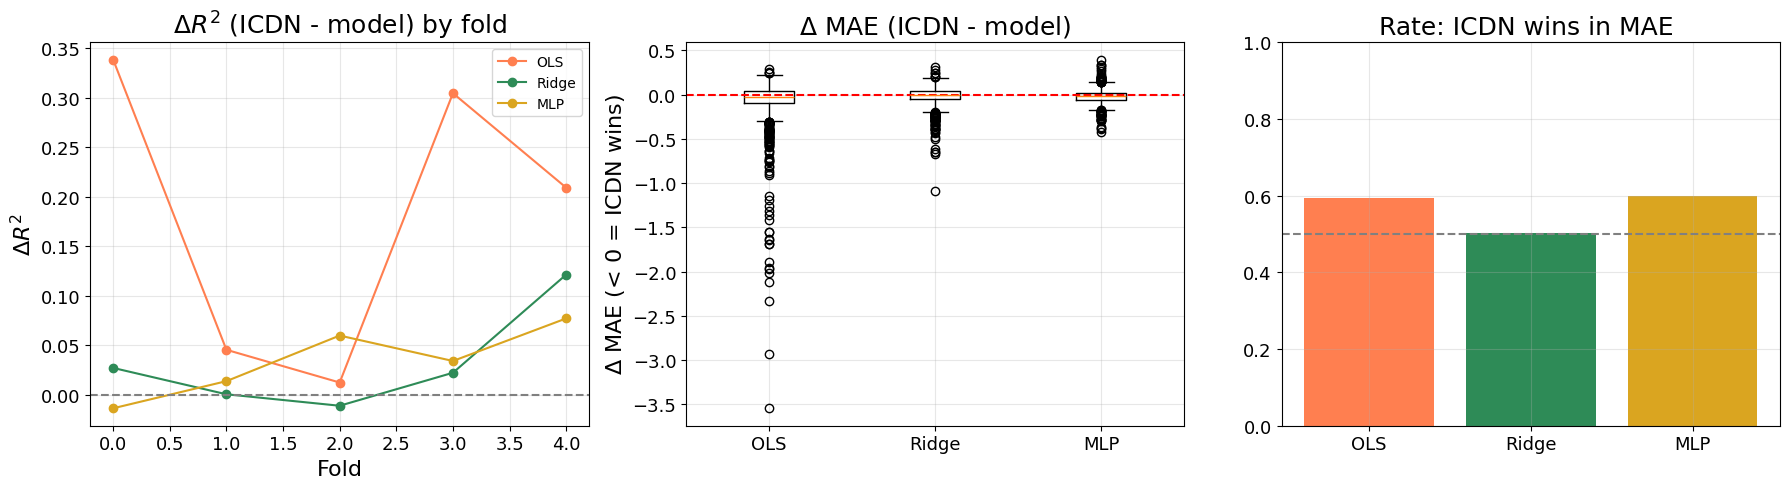

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
for label in MODEL_LABELS:
    sub = gen_fold_all[gen_fold_all["model"] == label]
    ax.plot(sub["fold"], sub["delta_r2"], marker="o", label=label, color=MODEL_COLORS[label])
ax.axhline(0, ls="--", color="gray")
ax.set_title(r"$\Delta R^2$ (ICDN - model) by fold")
ax.set_xlabel("Fold"); ax.set_ylabel(r"$\Delta R^2$")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
data = [gen_cell_all[gen_cell_all["model"] == l]["delta_mae"] for l in MODEL_LABELS]
ax.boxplot(data, labels=MODEL_LABELS)
ax.axhline(0, ls="--", color="red")
ax.set_title(r"$\Delta$ MAE (ICDN - model)")
ax.set_ylabel(r"$\Delta$ MAE (< 0 = ICDN wins)")
ax.grid(True, alpha=0.3)

ax = axes[2]
win_rates = [(gen_cell_all[gen_cell_all["model"] == l]["delta_mae"] < 0).mean() for l in MODEL_LABELS]
ax.bar(MODEL_LABELS, win_rates, color=[MODEL_COLORS[l] for l in MODEL_LABELS])
ax.axhline(0.5, ls="--", color="gray")
ax.set_title("Rate: ICDN wins in MAE ")
ax.set_ylim(0, 1); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# B2a - Own-elasticity stability

In [9]:
# ============================================================
# BLOCK 2 — Own-elasticity: A2 bootstrap + B temporal + A1 seeds
# ============================================================
BOOT_RAW_TABLES = {"OLS": bench_boot_raw, "Ridge": ridge_boot_raw, "MLP": mlp_boot_summary}


def collapsed_own_boot_stats(boot_raw_df: pd.DataFrame) -> pd.DataFrame:
    boot_ok = boot_raw_df[boot_raw_df["status"] == "ok"].copy() if "status" in boot_raw_df.columns else boot_raw_df.copy()
    per_run = boot_ok.groupby(["store_code", "upc_i", "bootstrap_run"], as_index=False).agg(
        own_elasticity=("own_elasticity", "mean")
    )
    return per_run.groupby(["store_code", "upc_i"], as_index=False).agg(
        elast_mean_o=("own_elasticity", "mean"),
        elast_std_o=("own_elasticity", "std"),
        ci_low_o=("own_elasticity", _q025),
        ci_high_o=("own_elasticity", _q975),
    )


def block2_own_stats(other_kfold: pd.DataFrame, other_boot_raw: pd.DataFrame):
    kfold_ok = other_kfold[other_kfold["status"] == "ok"].copy() if "status" in other_kfold.columns else other_kfold.copy()

    o_own_boot = collapsed_own_boot_stats(other_boot_raw)
    o_own_boot["ci_width_o"] = o_own_boot["ci_high_o"] - o_own_boot["ci_low_o"]
    elas_cmp = nn_boot_own.merge(o_own_boot, left_on=["store_code", "upc_code"], right_on=["store_code", "upc_i"])
    elas_cmp["ci_width_nn"]      = elas_cmp["elasticity_ci_high"] - elas_cmp["elasticity_ci_low"]
    elas_cmp["icdn_narrower_ci"] = elas_cmp["ci_width_nn"] < elas_cmp["ci_width_o"]
    elas_cmp["icdn_lower_std"]   = elas_cmp["elasticity_std"] < elas_cmp["elast_std_o"]
    elas_cmp["same_sign"]        = np.sign(elas_cmp["elasticity_mean"]) == np.sign(elas_cmp["elast_mean_o"])

    o_fold_E = kfold_ok.groupby(["store_code", "upc_i", "fold"], as_index=False).agg(
        own_elast=("own_elasticity", "mean")
    )
    o_temporal = o_fold_E.groupby(["store_code", "upc_i"], as_index=False).agg(
        E_temporal_std_o=("own_elast", "std"), n_folds_o=("own_elast", "count"),
    )
    temporal_cmp = nn_temporal_std_ref.merge(o_temporal, on=["store_code", "upc_i"])
    temporal_cmp = temporal_cmp[(temporal_cmp["n_folds"] >= 3) & (temporal_cmp["n_folds_o"] >= 3)]
    temporal_cmp["icdn_more_variable"] = (
        temporal_cmp["E_temporal_std"] > temporal_cmp["E_temporal_std_o"]
    )
    return elas_cmp, temporal_cmp, o_fold_E


elas_cmp_all, temporal_cmp_all, own_fold_E_all = [], [], []
for label in MODEL_LABELS:
    ec, temporal_cmp, ofe = block2_own_stats(MODEL_TABLES[label]["kfold"], BOOT_RAW_TABLES[label])
    ec["model"], temporal_cmp["model"], ofe["model"] = label, label, label
    elas_cmp_all.append(ec)
    temporal_cmp_all.append(temporal_cmp)
    own_fold_E_all.append(ofe)

elas_cmp_all     = pd.concat(elas_cmp_all, ignore_index=True)
temporal_cmp_all = pd.concat(temporal_cmp_all, ignore_index=True)
own_fold_E_all   = pd.concat(own_fold_E_all, ignore_index=True)

own_stability_summary = (
    elas_cmp_all.groupby("model", as_index=False)
    .agg(
        n_series=("icdn_narrower_ci", "size"),
        icdn_narrower_ci_rate=("icdn_narrower_ci", "mean"),
        icdn_lower_std_rate=("icdn_lower_std", "mean"),
        same_sign_rate=("same_sign", "mean"),
        median_ci_width_icdn=("ci_width_nn", "median"),
        median_ci_width_model=("ci_width_o", "median"),
    )
)
print("=== A2: own-elasticity bootstrap stability (same holdout) ===")
display(own_stability_summary)

temporal_own_summary = (
    temporal_cmp_all.groupby("model", as_index=False)
    .agg(
        n_series=("icdn_more_variable", "size"),
        icdn_more_variable_rate=("icdn_more_variable", "mean"),
        median_temporal_std_icdn=("E_temporal_std", "median"),
        median_temporal_std_model=("E_temporal_std_o", "median"),
    )
)
print("=== B: own-elasticity temporal variation (NOT estimator reproducibility) ===")
display(temporal_own_summary)

seed_cmp_own = nn_own_seed_ref.merge(
    mlp_own_seed_ref,
    on=["store_code", "upc_i", "fold"],
    suffixes=("_icdn", "_mlp"),
)
seed_cmp_own = seed_cmp_own[(seed_cmp_own["n_seeds_icdn"] >= 3) & (seed_cmp_own["n_seeds_mlp"] >= 3)]
seed_cmp_own["icdn_more_reproducible"] = seed_cmp_own["E_seed_std_icdn"] < seed_cmp_own["E_seed_std_mlp"]

seed_own_summary = pd.DataFrame([{
    "model": "MLP",
    "n_cells": len(seed_cmp_own),
    "icdn_more_reproducible_rate": seed_cmp_own["icdn_more_reproducible"].mean(),
    "median_seed_std_icdn": seed_cmp_own["E_seed_std_icdn"].median(),
    "median_seed_std_mlp": seed_cmp_own["E_seed_std_mlp"].median(),
    "median_seed_mad_icdn": seed_cmp_own["E_seed_mad_icdn"].median(),
    "median_seed_mad_mlp": seed_cmp_own["E_seed_mad_mlp"].median(),
}])
print("=== A1: own-elasticity seed reproducibility (same fold, same weeks) ===")
display(seed_own_summary)

=== A2: own-elasticity bootstrap stability (same holdout) ===


,model,n_series,icdn_narrower_ci_rate,icdn_lower_std_rate,same_sign_rate,median_ci_width_icdn,median_ci_width_model
0,MLP,212,0.033019,0.042453,1.000000,1.481317,0.275737
1,OLS,212,0.905660,0.924528,0.990566,1.481317,2.563271
2,Ridge,212,0.787736,0.806604,0.990566,1.481317,2.404371


=== B: own-elasticity temporal variation (NOT estimator reproducibility) ===


,model,n_series,icdn_more_variable_rate,median_temporal_std_icdn,median_temporal_std_model
0,MLP,274,1.000000,0.787145,0.079182
1,OLS,272,0.555147,0.787145,0.602627
2,Ridge,272,0.613971,0.787145,0.568584


=== A1: own-elasticity seed reproducibility (same fold, same weeks) ===


,model,n_cells,icdn_more_reproducible_rate,median_seed_std_icdn,median_seed_std_mlp,median_seed_mad_icdn,median_seed_mad_mlp
0,MLP,1272,0.226415,0.254162,0.095025,0.13171,0.046288


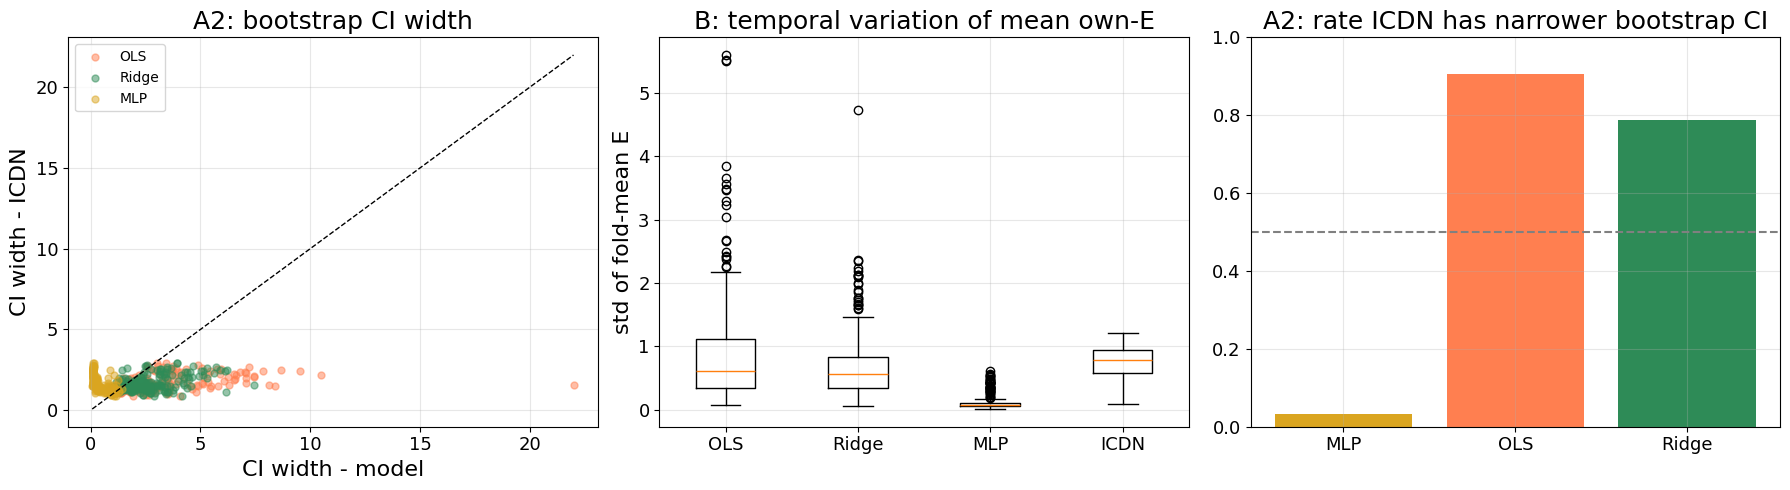

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
for label in MODEL_LABELS:
    sub = elas_cmp_all[elas_cmp_all["model"] == label]
    ax.scatter(sub["ci_width_o"], sub["ci_width_nn"], alpha=0.5, s=25, label=label, color=MODEL_COLORS[label])
lims = [elas_cmp_all["ci_width_o"].min(), elas_cmp_all["ci_width_o"].max()]
ax.plot(lims, lims, "k--", lw=1)
ax.set_xlabel("CI width - model")
ax.set_ylabel("CI width - ICDN")
ax.set_title("A2: bootstrap CI width")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
data = [temporal_cmp_all[temporal_cmp_all["model"] == l]["E_temporal_std_o"].dropna() for l in MODEL_LABELS]
data.append(nn_temporal_std_ref["E_temporal_std"].dropna())
ax.boxplot(data, tick_labels=MODEL_LABELS + ["ICDN"])
ax.set_title("B: temporal variation of mean own-E")
ax.set_ylabel("std of fold-mean E")
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.bar(
    own_stability_summary["model"],
    own_stability_summary["icdn_narrower_ci_rate"],
    color=[MODEL_COLORS[m] for m in own_stability_summary["model"]],
)
ax.axhline(0.5, ls="--", color="gray")
ax.set_title("A2: rate ICDN has narrower bootstrap CI")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# B2b - Cross-elasticity stability

In [11]:
# ============================================================
# BLOCK 2 cross — A2 bootstrap + B temporal + A1 seeds
# ============================================================
def block2_cross_stats(other_kfold: pd.DataFrame, other_boot_sum: pd.DataFrame):
    kfold_ok = other_kfold[other_kfold["status"] == "ok"].copy() if "status" in other_kfold.columns else other_kfold.copy()

    o_cross_boot = other_boot_sum[[
        "store_code", "upc_i", "upc_j",
        "cross_elasticity_mean", "cross_elasticity_std",
        "cross_elasticity_ci_low", "cross_elasticity_ci_high",
    ]].copy()
    o_cross_boot["ci_width_o"] = o_cross_boot["cross_elasticity_ci_high"] - o_cross_boot["cross_elasticity_ci_low"]

    nn_cross_boot_local = nn_boot_cross.copy()
    nn_cross_boot_local["ci_width_nn"] = nn_cross_boot_local["elasticity_ci_high"] - nn_cross_boot_local["elasticity_ci_low"]

    cross_cmp = nn_cross_boot_local.merge(o_cross_boot, on=["store_code", "upc_i", "upc_j"])
    cross_cmp["icdn_narrower_ci"] = cross_cmp["ci_width_nn"] < cross_cmp["ci_width_o"]
    cross_cmp["icdn_lower_std"]   = cross_cmp["elasticity_std"] < cross_cmp["cross_elasticity_std"]
    cross_cmp["same_sign"]        = np.sign(cross_cmp["elasticity_mean"]) == np.sign(cross_cmp["cross_elasticity_mean"])

    o_cross_fold_E = kfold_ok.groupby(["store_code", "upc_i", "upc_j", "fold"], as_index=False).agg(
        cross_elast=("cross_elasticity", "mean")
    )
    o_temporal = o_cross_fold_E.groupby(["store_code", "upc_i", "upc_j"], as_index=False).agg(
        E_temporal_std_o=("cross_elast", "std"), n_folds_o=("cross_elast", "count"),
    )
    temporal_cmp = nn_cross_temporal_std_ref.merge(o_temporal, on=["store_code", "upc_i", "upc_j"])
    temporal_cmp = temporal_cmp[(temporal_cmp["n_folds"] >= 3) & (temporal_cmp["n_folds_o"] >= 3)]
    temporal_cmp["icdn_more_variable"] = (
        temporal_cmp["E_temporal_std"] > temporal_cmp["E_temporal_std_o"]
    )
    return cross_cmp, temporal_cmp


cross_cmp_all, cross_temporal_cmp_all = [], []
for label in MODEL_LABELS:
    cc, ctc = block2_cross_stats(MODEL_TABLES[label]["kfold"], MODEL_TABLES[label]["boot_sum"])
    cc["model"], ctc["model"] = label, label
    cross_cmp_all.append(cc)
    cross_temporal_cmp_all.append(ctc)
cross_cmp_all          = pd.concat(cross_cmp_all, ignore_index=True)
cross_temporal_cmp_all = pd.concat(cross_temporal_cmp_all, ignore_index=True)

cross_stability_summary = (
    cross_cmp_all.groupby("model", as_index=False)
    .agg(
        n_pairs=("icdn_narrower_ci", "size"),
        icdn_narrower_ci_rate=("icdn_narrower_ci", "mean"),
        icdn_lower_std_rate=("icdn_lower_std", "mean"),
        same_sign_rate=("same_sign", "mean"),
        median_cross_elast_icdn=("elasticity_mean", "median"),
        median_cross_elast_model=("cross_elasticity_mean", "median"),
    )
)
print("=== A2: cross-elasticity bootstrap stability (same holdout) ===")
display(cross_stability_summary)

temporal_cross_summary = (
    cross_temporal_cmp_all.groupby("model", as_index=False)
    .agg(
        n_pairs=("icdn_more_variable", "size"),
        icdn_more_variable_rate=("icdn_more_variable", "mean"),
        median_temporal_std_icdn=("E_temporal_std", "median"),
        median_temporal_std_model=("E_temporal_std_o", "median"),
    )
)
print("=== B: cross-elasticity temporal variation (NOT estimator reproducibility) ===")
display(temporal_cross_summary)

seed_cmp_cross = nn_cross_seed_ref.merge(
    mlp_cross_seed_ref,
    on=["store_code", "upc_i", "upc_j", "fold"],
    suffixes=("_icdn", "_mlp"),
)
seed_cmp_cross = seed_cmp_cross[(seed_cmp_cross["n_seeds_icdn"] >= 3) & (seed_cmp_cross["n_seeds_mlp"] >= 3)]
seed_cmp_cross["icdn_more_reproducible"] = seed_cmp_cross["E_seed_std_icdn"] < seed_cmp_cross["E_seed_std_mlp"]

seed_cross_summary = pd.DataFrame([{
    "model": "MLP",
    "n_cells": len(seed_cmp_cross),
    "icdn_more_reproducible_rate": seed_cmp_cross["icdn_more_reproducible"].mean(),
    "median_seed_std_icdn": seed_cmp_cross["E_seed_std_icdn"].median(),
    "median_seed_std_mlp": seed_cmp_cross["E_seed_std_mlp"].median(),
    "median_seed_mad_icdn": seed_cmp_cross["E_seed_mad_icdn"].median(),
    "median_seed_mad_mlp": seed_cmp_cross["E_seed_mad_mlp"].median(),
}])
print("=== A1: cross-elasticity seed reproducibility (same fold, same weeks) ===")
display(seed_cross_summary)

=== A2: cross-elasticity bootstrap stability (same holdout) ===


,model,n_pairs,icdn_narrower_ci_rate,icdn_lower_std_rate,same_sign_rate,median_cross_elast_icdn,median_cross_elast_model
0,MLP,544,0.031250,0.042279,0.220588,0.342342,-0.025649
1,OLS,544,0.970588,0.977941,0.435662,0.342342,-0.260106
2,Ridge,544,0.895221,0.902574,0.411765,0.342342,-0.248564


=== B: cross-elasticity temporal variation (NOT estimator reproducibility) ===


,model,n_pairs,icdn_more_variable_rate,median_temporal_std_icdn,median_temporal_std_model
0,MLP,962,0.968815,0.171155,0.036433
1,OLS,948,0.271097,0.171155,0.296823
2,Ridge,948,0.424051,0.171155,0.197838


=== A1: cross-elasticity seed reproducibility (same fold, same weeks) ===


,model,n_cells,icdn_more_reproducible_rate,median_seed_std_icdn,median_seed_std_mlp,median_seed_mad_icdn,median_seed_mad_mlp
0,MLP,3976,0.170272,0.101361,0.048751,0.056422,0.024321


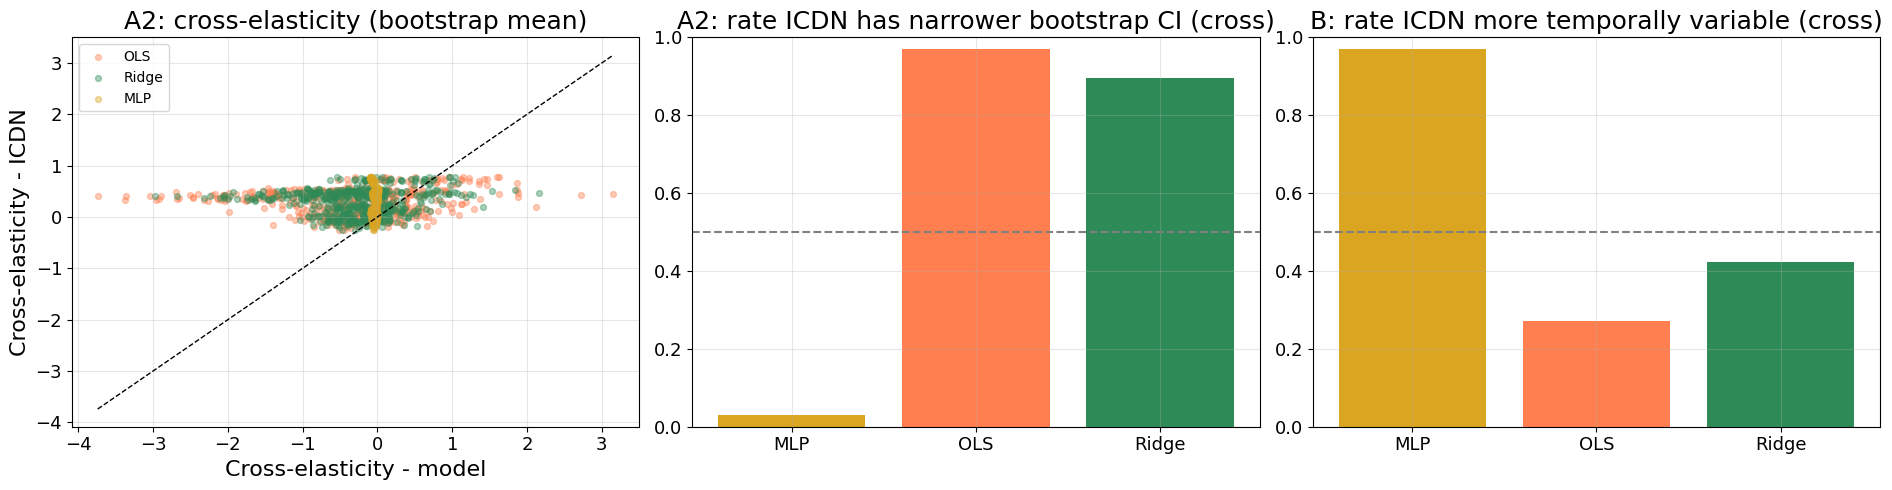

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

ax = axes[0]
for label in MODEL_LABELS:
    sub = cross_cmp_all[cross_cmp_all["model"] == label]
    ax.scatter(
        sub["cross_elasticity_mean"], sub["elasticity_mean"],
        alpha=0.4, s=18, label=label, color=MODEL_COLORS[label],
    )
lims = [
    cross_cmp_all["cross_elasticity_mean"].min(),
    cross_cmp_all["cross_elasticity_mean"].max(),
]
ax.plot(lims, lims, "k--", lw=1)
ax.set_xlabel("Cross-elasticity - model")
ax.set_ylabel("Cross-elasticity - ICDN")
ax.set_title("A2: cross-elasticity (bootstrap mean)")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.bar(
    cross_stability_summary["model"],
    cross_stability_summary["icdn_narrower_ci_rate"],
    color=[MODEL_COLORS[m] for m in cross_stability_summary["model"]],
)
ax.axhline(0.5, ls="--", color="gray")
ax.set_title("A2: rate ICDN has narrower bootstrap CI (cross)")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.bar(
    temporal_cross_summary["model"],
    temporal_cross_summary["icdn_more_variable_rate"],
    color=[MODEL_COLORS[m] for m in temporal_cross_summary["model"]],
)
ax.axhline(0.5, ls="--", color="gray")
ax.set_title("B: rate ICDN more temporally variable (cross)")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# B3 - Calibration + dispersion ratio

In [13]:
# ============================================================
# BLOCK 3 — Coverage (mixed windows) + separate dispersions
# ============================================================
nn_calib_ref = nn_kfold_point_ref.merge(
    nn_boot_own[["store_code", "upc_code", "elasticity_ci_low", "elasticity_ci_high"]],
    left_on=["store_code", "upc_i"], right_on=["store_code", "upc_code"],
)
nn_calib_ref["covered"] = (
    (nn_calib_ref["E_fold"] >= nn_calib_ref["elasticity_ci_low"])
    & (nn_calib_ref["E_fold"] <= nn_calib_ref["elasticity_ci_high"])
)
nn_cov_own_ref = nn_calib_ref["covered"].mean()

nn_cross_calib_ref = nn_cross_fold_E_ref.merge(
    nn_boot_cross[["store_code", "upc_i", "upc_j", "elasticity_ci_low", "elasticity_ci_high"]],
    on=["store_code", "upc_i", "upc_j"],
)
nn_cross_calib_ref["covered"] = (
    (nn_cross_calib_ref["E_mean"] >= nn_cross_calib_ref["elasticity_ci_low"])
    & (nn_cross_calib_ref["E_mean"] <= nn_cross_calib_ref["elasticity_ci_high"])
)
nn_cov_cross_ref = nn_cross_calib_ref["covered"].mean()

OWN_BOOT_SUMMARIES = {label: collapsed_own_boot_stats(BOOT_RAW_TABLES[label]) for label in MODEL_LABELS}


def block3_tables(other_kfold, own_boot_summary, other_boot_sum):
    kfold_ok = other_kfold[other_kfold["status"] == "ok"].copy() if "status" in other_kfold.columns else other_kfold.copy()

    o_fold_E = kfold_ok.groupby(["store_code", "upc_i", "fold"], as_index=False).agg(
        own_elast=("own_elasticity", "mean")
    )
    o_ci = own_boot_summary[["store_code", "upc_i", "ci_low_o", "ci_high_o"]]
    o_calib = o_fold_E.merge(o_ci, on=["store_code", "upc_i"])
    o_calib["covered"] = (o_calib["own_elast"] >= o_calib["ci_low_o"]) & (o_calib["own_elast"] <= o_calib["ci_high_o"])

    o_cross_fold_E = kfold_ok.groupby(["store_code", "upc_i", "upc_j", "fold"], as_index=False).agg(
        cross_elast=("cross_elasticity", "mean")
    )
    o_cross_ci = other_boot_sum[["store_code", "upc_i", "upc_j", "cross_elasticity_ci_low", "cross_elasticity_ci_high"]]
    o_cross_calib = o_cross_fold_E.merge(o_cross_ci, on=["store_code", "upc_i", "upc_j"])
    o_cross_calib["covered"] = (
        (o_cross_calib["cross_elast"] >= o_cross_calib["cross_elasticity_ci_low"])
        & (o_cross_calib["cross_elast"] <= o_cross_calib["cross_elasticity_ci_high"])
    )

    o_temporal = o_fold_E.groupby(["store_code", "upc_i"], as_index=False).agg(
        E_temporal_std_o=("own_elast", "std")
    )
    o_cross_temporal = o_cross_fold_E.groupby(["store_code", "upc_i", "upc_j"], as_index=False).agg(
        E_temporal_std_o=("cross_elast", "std")
    )
    return o_calib, o_cross_calib, o_temporal, o_cross_temporal


coverage_rows, disp_rows = [], []
coverage_rows.append({"model": "ICDN", "coverage_95_own": nn_cov_own_ref, "coverage_95_cross": nn_cov_cross_ref})
disp_rows.append({
    "model": "ICDN",
    "median_bootstrap_std_own": nn_boot_own["elasticity_std"].median(),
    "median_temporal_std_own": nn_temporal_std_ref["E_temporal_std"].median(),
    "median_bootstrap_std_cross": nn_boot_cross["elasticity_std"].median(),
    "median_temporal_std_cross": nn_cross_temporal_std_ref["E_temporal_std"].median(),
})

for label in MODEL_LABELS:
    o_calib, o_cross_calib, o_temporal, o_cross_temporal = block3_tables(
        MODEL_TABLES[label]["kfold"], OWN_BOOT_SUMMARIES[label], MODEL_TABLES[label]["boot_sum"]
    )
    coverage_rows.append({
        "model": label,
        "coverage_95_own": o_calib["covered"].mean(),
        "coverage_95_cross": o_cross_calib["covered"].mean(),
    })
    disp_rows.append({
        "model": label,
        "median_bootstrap_std_own": OWN_BOOT_SUMMARIES[label]["elast_std_o"].median(),
        "median_temporal_std_own": o_temporal["E_temporal_std_o"].median(),
        "median_bootstrap_std_cross": MODEL_TABLES[label]["boot_sum"]["cross_elasticity_std"].median(),
        "median_temporal_std_cross": o_cross_temporal["E_temporal_std_o"].median(),
    })

coverage_table = pd.DataFrame(coverage_rows)
dispersion_table = pd.DataFrame(disp_rows)

print("=== Coverage of k-fold points inside bootstrap CI (MIXED windows; not a calibration of the same estimand) ===")
display(coverage_table)
print("=== Dispersion: A2 bootstrap std vs B temporal std (report separately; no ideal ratio) ===")
display(dispersion_table)

=== Coverage of k-fold points inside bootstrap CI (MIXED windows; not a calibration of the same estimand) ===


,model,coverage_95_own,coverage_95_cross
0,ICDN,0.715079,0.811349
1,OLS,0.865586,0.907709
2,Ridge,0.809342,0.922535
3,MLP,0.468307,0.750921


=== Dispersion: A2 bootstrap std vs B temporal std (report separately; no ideal ratio) ===


,model,median_bootstrap_std_own,median_temporal_std_own,median_bootstrap_std_cross,median_temporal_std_cross
0,ICDN,0.447809,0.786156,0.170350,0.171328
1,OLS,0.764345,0.618995,0.539109,0.298102
2,Ridge,0.716885,0.574938,0.401446,0.197838
3,MLP,0.080721,0.079182,0.044386,0.036323


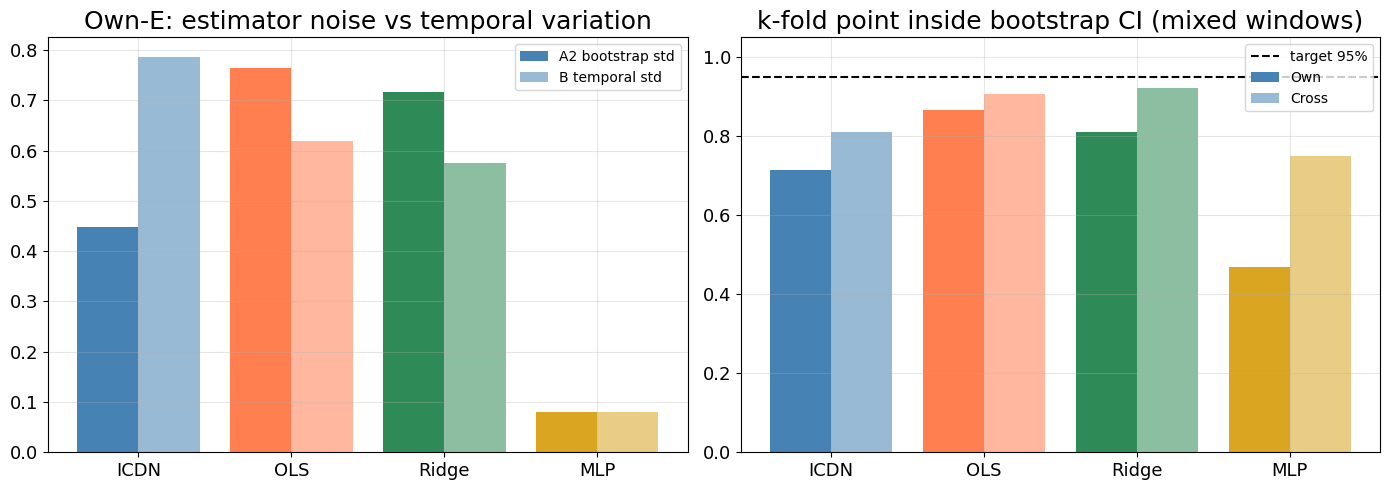

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ["ICDN"] + MODEL_LABELS
colors = [MODEL_COLORS[m] for m in order]
x = np.arange(len(order))
disp_idx = dispersion_table.set_index("model").loc[order]
cov_idx = coverage_table.set_index("model").loc[order]

ax = axes[0]
ax.bar(x - 0.2, disp_idx["median_bootstrap_std_own"], width=0.4, label="A2 bootstrap std", color=colors)
ax.bar(x + 0.2, disp_idx["median_temporal_std_own"], width=0.4, label="B temporal std", color=colors, alpha=0.55)
ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_title("Own-E: estimator noise vs temporal variation")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.bar(x - 0.2, cov_idx["coverage_95_own"], width=0.4, label="Own", color=colors)
ax.bar(x + 0.2, cov_idx["coverage_95_cross"], width=0.4, label="Cross", color=colors, alpha=0.55)
ax.axhline(0.95, ls="--", color="black", label="target 95%")
ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_title("k-fold point inside bootstrap CI (mixed windows)")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# B4 - Summary

In [15]:
final_comparison_table = (
    gen_fold_all.groupby("model", as_index=False).agg(delta_r2_vs_icdn=("delta_r2", "mean"))
    .merge(own_stability_summary[["model", "icdn_narrower_ci_rate", "same_sign_rate"]], on="model")
    .merge(
        temporal_own_summary[["model", "icdn_more_variable_rate", "median_temporal_std_model"]],
        on="model",
    )
    .merge(
        dispersion_table[dispersion_table["model"] != "ICDN"][["model", "median_bootstrap_std_own"]],
        on="model",
    )
    .set_index("model")
)
display(final_comparison_table)
final_comparison_table.to_csv("../data/final_model_comparison_table.csv")
print("Saved: final_model_comparison_table.csv")
print("A1 seed reproducibility vs MLP is in seed_own_summary / seed_cross_summary (not in this table).")

,delta_r2_vs_icdn,icdn_narrower_ci_rate,same_sign_rate,icdn_more_variable_rate,median_temporal_std_model,median_bootstrap_std_own
model,,,,,,
MLP,0.034281,0.033019,1.000000,1.000000,0.079182,0.080721
OLS,0.182039,0.905660,0.990566,0.555147,0.602627,0.764345
Ridge,0.032084,0.787736,0.990566,0.613971,0.568584,0.716885


Saved: final_model_comparison_table.csv
A1 seed reproducibility vs MLP is in seed_own_summary / seed_cross_summary (not in this table).
